In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("../data/processed/crop_clean.csv")

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
X = df.drop("label", axis=1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
models = {

"Logistic Regression": LogisticRegression(max_iter=1000),

"KNN": KNeighborsClassifier(),

"SVM": SVC(),

"Decision Tree": DecisionTreeClassifier(),

"Random Forest": RandomForestClassifier()

}

accuracies = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    accuracies.append(acc)

    print(name, "Accuracy:", acc)

C:\Users\prane\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.95
KNN Accuracy: 0.9704545454545455
SVM Accuracy: 0.9613636363636363
Decision Tree Accuracy: 0.9818181818181818
Random Forest Accuracy: 0.9931818181818182


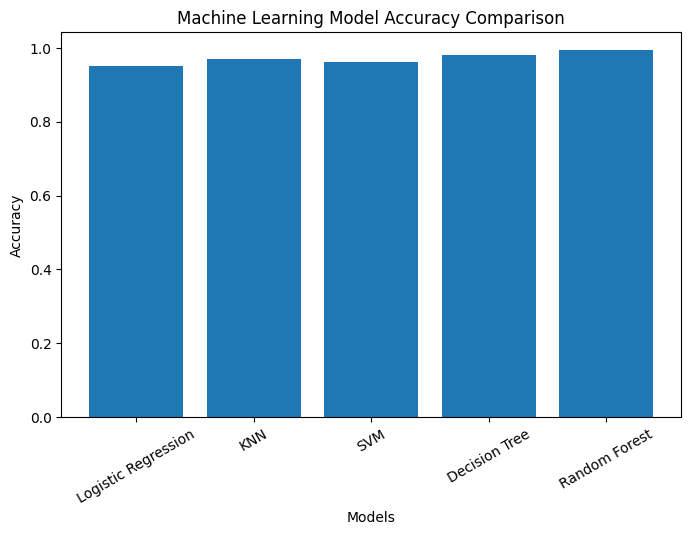

In [5]:
plt.figure(figsize=(8,5))

plt.bar(models.keys(), accuracies)

plt.title("Machine Learning Model Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.xticks(rotation=30)

plt.show()

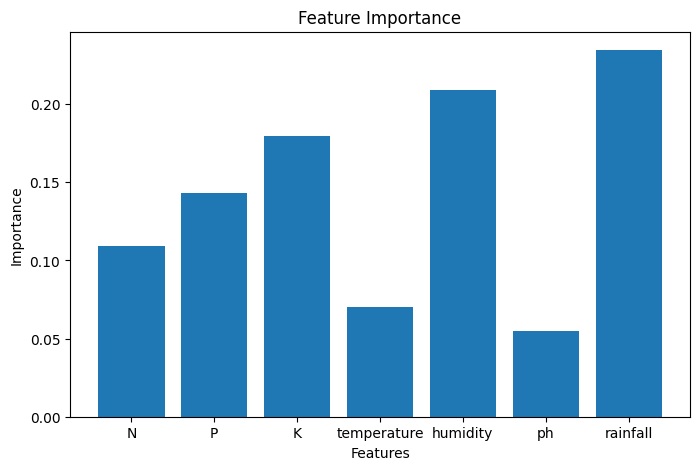

In [6]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

importance = rf.feature_importances_

plt.figure(figsize=(8,5))

plt.bar(X.columns, importance)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.show()

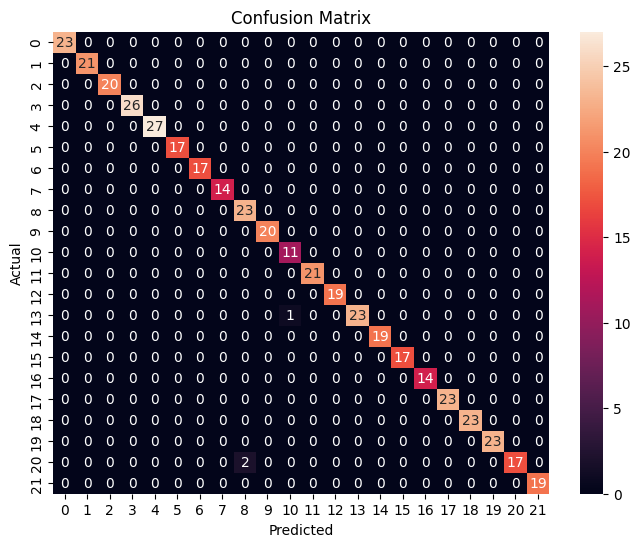

In [7]:
pred = rf.predict(X_test)

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()